<a href="https://colab.research.google.com/github/Boyapatinirosha/README/blob/main/Copy_of_hand_gesture_recognization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: install libs (run once)
!pip install mediapipe opencv-python-headless scikit-learn numpy pandas joblib matplotlib



<IPython.core.display.Javascript object>

Saved photo to: photo.jpg


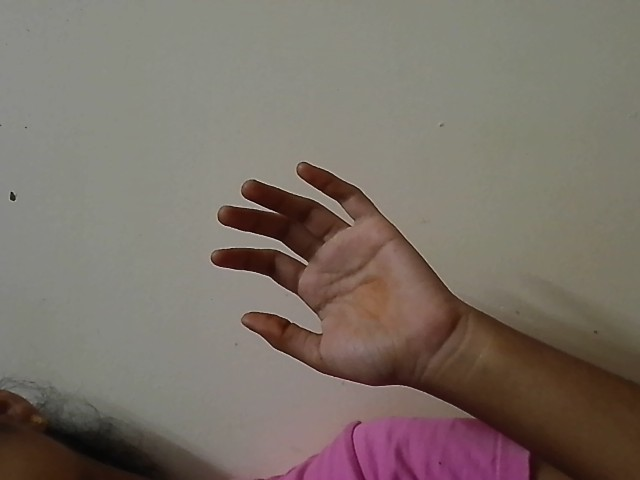

In [ ]:
# Cell 2: webcam capture helper - click "Capture" to take one photo and save it
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
import base64, cv2, numpy as np

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript("""
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      capture.style.fontSize = '16px';
      div.appendChild(capture);
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      div.appendChild(video);
      document.body.appendChild(div);
      video.srcObject = stream;
      await video.play();
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
      await new Promise((resolve) => capture.onclick = resolve);
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      video.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    """)
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = base64.b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

# Example: take one photo (click Capture)
fname = take_photo('photo.jpg', quality=0.9)
print("Saved photo to:", fname)
display(Image(fname))



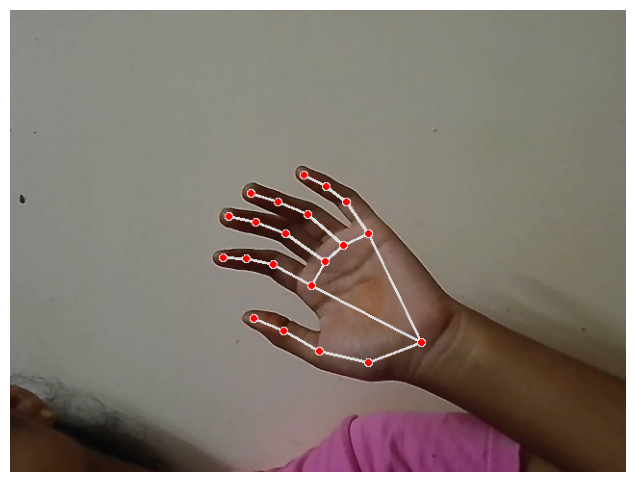

In [ ]:
# Cell 3: run MediaPipe Hands on the saved image and show result
import cv2, mediapipe as mp
from matplotlib import pyplot as plt

mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5)

img = cv2.imread('photo.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
res = hands.process(img_rgb)

if res.multi_hand_landmarks:
    for lm in res.multi_hand_landmarks:
        mp_draw.draw_landmarks(img, lm, mp_hands.HAND_CONNECTIONS)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


In [ ]:
# Cell 4: manual data collection - change labels & samples_per_label as needed
labels = ['thumbs_up','stop','victory']     # change to your gestures
samples_per_label = 3                      # how many photos per label

print("You will be prompted to capture images for each label.")
for label in labels:
    print(f"\n== Prepare for label: {label} -> {samples_per_label} samples ==")
    for i in range(samples_per_label):
        fname = f"{label}_{i+1}.jpg"
        print(f"  Capture sample {i+1}/{samples_per_label} for '{label}' (click Capture)...")
        take_photo(fname, quality=0.8)
    print(f"Done label: {label}")

print("\nAll captures complete. Use the Files pane (left) to inspect images if needed.")


You will be prompted to capture images for each label.

== Prepare for label: thumbs_up -> 3 samples ==
  Capture sample 1/3 for 'thumbs_up' (click Capture)...


<IPython.core.display.Javascript object>

  Capture sample 2/3 for 'thumbs_up' (click Capture)...


<IPython.core.display.Javascript object>

  Capture sample 3/3 for 'thumbs_up' (click Capture)...


...

  Capture sample 2/3 for 'victory' (click Capture)...


<IPython.core.display.Javascript object>

  Capture sample 3/3 for 'victory' (click Capture)...


<IPython.core.display.Javascript object>

Done label: victory

All captures complete. Use the Files pane (left) to inspect images if needed.


In [ ]:
# Cell 5: extract landmarks from collected images and save gestures.csv
import os, csv, mediapipe as mp, cv2
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5)

header = ['label'] + [f'x{i}' for i in range(21)] + [f'y{i}' for i in range(21)]
rows = []
for file in sorted(os.listdir('.')):
    if file.lower().endswith('.jpg'):
        for label in labels:
            if file.startswith(label):
                img = cv2.imread(file)
                rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                res = hands.process(rgb)
                if res.multi_hand_landmarks:
                    lm = res.multi_hand_landmarks[0].landmark
                    xs = [p.x for p in lm]
                    ys = [p.y for p in lm]
                    rows.append([label] + xs + ys)
                else:
                    print("No hand detected in", file)

with open('gestures.csv','w',newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(rows)

print("Saved gestures.csv with", len(rows), "rows.")
# show counts per label
from collections import Counter
print("Counts:", Counter([r[0] for r in rows]))


No hand detected in thumbs_up_8.jpg
Saved gestures.csv with 62 rows.
Counts: Counter({'stop': 30, 'thumbs_up': 29, 'victory': 3})


In [ ]:
# Cell 6: train a classifier (normalizing landmarks w.r.t wrist)
import pandas as pd, numpy as np, joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

df = pd.read_csv('gestures.csv')
def normalize_row(row):
    xs = np.array(row[:21]).astype(float)
    ys = np.array(row[21:]).astype(float)
    pts = np.stack([xs, ys], axis=1)
    pts = pts - pts[0]                # wrist as origin
    m = np.linalg.norm(pts, axis=1).max()
    if m == 0: m = 1.0
    pts = pts / m
    return pts.flatten()

X_raw = df.iloc[:,1:].values
X = np.array([normalize_row(r) for r in X_raw])
y = df['label'].values
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, stratify=y_enc, random_state=42)
clf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", acc)
print("\nClassification report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

joblib.dump({'model': clf, 'le': le}, 'gesture_rf.joblib')
print("Saved model to gesture_rf.joblib")


Test accuracy: 1.0

Classification report:
               precision    recall  f1-score   support

        stop       1.00      1.00      1.00         6
   thumbs_up       1.00      1.00      1.00         6
     victory       1.00      1.00      1.00         1

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13

Saved model to gesture_rf.joblib


<IPython.core.display.Javascript object>

Captured test.jpg
Predicted gesture: stop


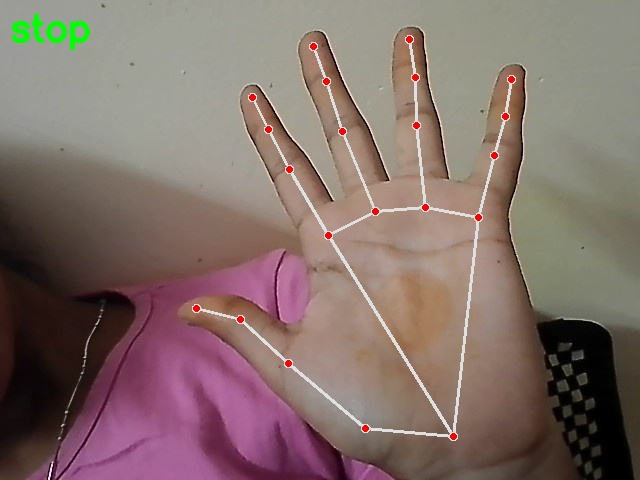

In [ ]:
# Cell 7: capture a test photo then predict and show annotated image
import joblib, cv2, mediapipe as mp, numpy as np
from IPython.display import display, Image
from matplotlib import pyplot as plt

# capture test image (click Capture)
test_fname = take_photo('test.jpg', quality=0.9)
print("Captured", test_fname)

# load model
data = joblib.load('gesture_rf.joblib')
clf, le = data['model'], data['le']

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1)

img = cv2.imread(test_fname)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
res = hands.process(rgb)

if res.multi_hand_landmarks:
    lm = res.multi_hand_landmarks[0].landmark
    xs = np.array([p.x for p in lm])
    ys = np.array([p.y for p in lm])
    pts = np.stack([xs, ys], axis=1)
    pts = pts - pts[0]
    m = np.linalg.norm(pts, axis=1).max()
    if m == 0: m = 1.0
    feat = (pts / m).flatten().reshape(1, -1)
    pred = clf.predict(feat)[0]
    label = le.inverse_transform([pred])[0]
    # draw landmarks and put label text on image
    import mediapipe as mp2
    mp_draw = mp2.solutions.drawing_utils
    mp_draw.draw_landmarks(img, res.multi_hand_landmarks[0], mp2.solutions.hands.HAND_CONNECTIONS)
    cv2.putText(img, f"{label}", (10,40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,255,0), 3)
    result_fname = 'predicted_test.jpg'
    cv2.imwrite(result_fname, img)
    print("Predicted gesture:", label)
    display(Image(result_fname))
else:
    print("No hand detected in test photo.")
    display(Image(test_fname))


In [ ]:
# Cell 8: download files to your local machine
from google.colab import files
files.download('gestures.csv')
files.download('gesture_rf.joblib')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>